# 03d — TerSeg (Dual-Branch CNN + Swin Transformer)
**Paper:** Fan et al., Expert Systems with Applications 270 (2025) 126397. DOI: 10.1016/j.eswa.2025.126397

## 0. Configuración

In [4]:
import sys; sys.path.append('.')
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, numpy as np
from mars_utils_fast import (
    set_seed, get_or_create_split, build_dataloaders,
    run_multi_seed, append_benchmark_results,
    visualize_predictions, count_parameters,
    FocalLoss, NUM_CLASSES, IGNORE_INDEX
)
set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
MODEL_NAME = "terseg"
try:
    import timm
    print(f"timm {timm.__version__} disponible")
except ImportError:
    print("timm no instalado. Ejecuta: pip install timm")


Device: cuda
timm 1.0.26 disponible


## 1. Dataset

In [5]:
df = pd.read_csv("processed/manifest_256.csv")
df_train, df_val, df_test = get_or_create_split(df)
train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test, batch_size=8, num_workers=0
)


✅ Split cargado desde processed\split_indices.pkl
Train: 16074 {'MSL': 15901, 'MER': 173}
Val  :  3443 {'MSL': 3443}
Test :  3448 {'MSL': 3448}


## 2. Arquitectura TerSeg
Dual-branch: Branch_C (ResNet-34) + Branch_T (Swin-Tiny).
FL en etapas 1-2 (CNN domina), FG en etapas 3-4 (Transformer domina).
Decoder FLGA con conv 3×3 final.

In [6]:
import torchvision.models as tvm

class FusionModule(nn.Module):
    """FL o FG: fusión ponderada learnable entre ramas CNN y Transformer."""
    def __init__(self, cnn_ch, tr_ch, out_ch, cnn_dominant=True):
        super().__init__()
        self.cnn_proj = nn.Conv2d(cnn_ch, out_ch, 1, bias=False)
        self.tr_proj  = nn.Conv2d(tr_ch,  out_ch, 1, bias=False)
        # Pesos learnable inicializados según dominancia
        init_cnn = 0.7 if cnn_dominant else 0.3
        self.w_cnn = nn.Parameter(torch.tensor(init_cnn))
        self.w_tr  = nn.Parameter(torch.tensor(1.0 - init_cnn))
        self.norm  = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(True)

    def forward(self, r, t):
        # Alinear resoluciones si difieren
        if r.shape[-2:] != t.shape[-2:]:
            t = F.interpolate(t, size=r.shape[-2:], mode='bilinear', align_corners=False)
        return self.relu(self.norm(
            self.w_cnn * self.cnn_proj(r) + self.w_tr * self.tr_proj(t)
        ))

class FLGA(nn.Module):
    """Focus on Local & Global Aggregation: upsampling progresivo + conv 3×3."""
    def __init__(self, channels, num_classes):
        super().__init__()
        self.ups  = nn.ModuleList()
        self.convs= nn.ModuleList()
        ch = channels
        for i in range(len(ch)-1, 0, -1):
            self.ups.append(nn.Sequential(
                nn.Conv2d(ch[i], ch[i-1], 1, bias=False),
                nn.BatchNorm2d(ch[i-1]), nn.ReLU(True)
            ))
            self.convs.append(nn.Sequential(
                nn.Conv2d(ch[i-1]*2, ch[i-1], 3, padding=1, bias=False),
                nn.BatchNorm2d(ch[i-1]), nn.ReLU(True)
            ))
        self.head = nn.Conv2d(ch[0], num_classes, 1)

    def forward(self, features):
        # features: [f1, f2, f3, f4] de menor a mayor escala espacial
        x = features[-1]
        skips = features[:-1][::-1]
        for up, conv, skip in zip(self.ups, self.convs, skips):
            x = up(x)
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = conv(torch.cat([x, skip], dim=1))
        return self.head(x)

class TerSeg(nn.Module):
    """
    Dual-branch: Branch_C=ResNet34, Branch_T=Swin-Tiny.
    Configuración TC_S: out_ch=64 para las 4 etapas de fusión.
    ~22M params, ~26G FLOPs.
    """
    def __init__(self, num_classes=NUM_CLASSES, out_ch=64):
        super().__init__()
        # Branch C: ResNet-34
        bb = tvm.resnet34(weights=tvm.ResNet34_Weights.DEFAULT)
        self.c_stem  = nn.Sequential(bb.conv1,bb.bn1,bb.relu,bb.maxpool)
        self.c_layer1= bb.layer1   # 64ch,  /4
        self.c_layer2= bb.layer2   # 128ch, /8
        self.c_layer3= bb.layer3   # 256ch, /16
        self.c_layer4= bb.layer4   # 512ch, /32

        # Branch T: Swin-Tiny via timm
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True, features_only=True,
            out_indices=(0,1,2,3)
        )
        swin_chs = self.swin.feature_info.channels()  # [96,192,384,768]

        # Fusión FL (etapas 1,2 — CNN domina)
        self.fl1 = FusionModule(64,  swin_chs[0], out_ch, cnn_dominant=True)
        self.fl2 = FusionModule(128, swin_chs[1], out_ch, cnn_dominant=True)
        # Fusión FG (etapas 3,4 — Transformer domina)
        self.fg3 = FusionModule(256, swin_chs[2], out_ch, cnn_dominant=False)
        self.fg4 = FusionModule(512, swin_chs[3], out_ch, cnn_dominant=False)

        # Decoder FLGA
        self.flga = FLGA([out_ch]*4, num_classes)

    def forward(self, x):
        # Branch C
        c0 = self.c_stem(x)
        r1 = self.c_layer1(c0)
        r2 = self.c_layer2(r1)
        r3 = self.c_layer3(r2)
        r4 = self.c_layer4(r3)

        # Branch T (Swin espera múltiplo de 32)
        x_swin = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)
        t_feats = self.swin(x_swin)
        t1,t2,t3,t4 = [f.permute(0,3,1,2) if f.dim()==4 else f for f in t_feats]

        # Fusión
        f1 = self.fl1(r1, t1)
        f2 = self.fl2(r2, t2)
        f3 = self.fg3(r3, t3)
        f4 = self.fg4(r4, t4)

        out = self.flga([f1,f2,f3,f4])
        return F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)

def build_terseg():
    return TerSeg(NUM_CLASSES)

model = build_terseg().to(device)
params_M = count_parameters(model)
print(f"Parámetros: {params_M:.2f}M")
with torch.no_grad():
    dummy = torch.randn(2,3,256,256).to(device)
    print(f"Output: {model(dummy).shape}")


Parámetros: 49.19M
Output: torch.Size([2, 4, 256, 256])


## 3. Entrenamiento (3 seeds)
Adam + ReduceLROnPlateau, Focal Loss

In [7]:
import torch.optim as optim

def criterion_fn():
    return FocalLoss(alpha=0.25, gamma=2.0, ignore_index=IGNORE_INDEX)

def optimizer_fn(params):
    return optim.Adam(params, lr=1e-4)

def scheduler_fn(opt):
    return optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=5, factor=0.5)

summary = run_multi_seed(
    model_fn=build_terseg,
    df_train=df_train, df_val=df_val, df_test=df_test,
    criterion_fn=criterion_fn, optimizer_fn=optimizer_fn, scheduler_fn=scheduler_fn,
    model_name=MODEL_NAME, device=device,
    seeds=[42,123,7], num_epochs=80, patience=10, batch_size=10, num_workers=6, n_per_mission=700
)



──────────────────────────────────────────────────
  Seed 42 | terseg


c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  terseg_seed42 | device=cuda | AMP=True
Ep   1/80 | loss=0.0863 mIoU=0.4611 | val=0.5663 | rock=0.0208
Ep   2/80 | loss=0.0564 mIoU=0.5384 | val=0.6271 | rock=0.0152
Ep   3/80 | loss=0.0374 mIoU=0.5961 | val=0.6434 | rock=0.0041
Ep   4/80 | loss=0.0374 mIoU=0.5980 | val=0.6198 | rock=0.0268
Ep   5/80 | loss=0.0326 mIoU=0.6252 | val=0.7044 | rock=0.2683
Ep   6/80 | loss=0.0288 mIoU=0.6404 | val=0.6421 | rock=0.0669
Ep   7/80 | loss=0.0260 mIoU=0.6691 | val=0.7127 | rock=0.4078
Ep   8/80 | loss=0.0229 mIoU=0.7154 | val=0.7854 | rock=0.5201
Ep   9/80 | loss=0.0246 mIoU=0.7025 | val=0.6473 | rock=0.0390
Ep  10/80 | loss=0.0235 mIoU=0.6780 | val=0.7959 | rock=0.5121
Ep  11/80 | loss=0.0172 mIoU=0.7575 | val=0.7328 | rock=0.2860
Ep  12/80 | loss=0.0181 mIoU=0.7561 | val=0.8001 | rock=0.5352
Ep  13/80 | loss=0.0160 mIoU=0.7799 | val=0.8188 | rock=0.5427
Ep  14/80 | loss=0.0154 mIoU=0.7737 | val=0.7432 | rock=0.3138
Ep  15/80 | loss=0.0175 mIoU=0.7603 | val=0.7804 | rock=0.5018
Ep  16/80 | l

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  terseg_seed123 | device=cuda | AMP=True
Ep   1/80 | loss=0.0879 mIoU=0.4635 | val=0.6024 | rock=0.0904
Ep   2/80 | loss=0.0527 mIoU=0.5675 | val=0.7050 | rock=0.3004
Ep   3/80 | loss=0.0445 mIoU=0.5856 | val=0.6566 | rock=0.0267
Ep   4/80 | loss=0.0331 mIoU=0.6183 | val=0.6473 | rock=0.1862
Ep   5/80 | loss=0.0293 mIoU=0.6774 | val=0.6700 | rock=0.0286
Ep   6/80 | loss=0.0242 mIoU=0.6877 | val=0.7228 | rock=0.1949
Ep   7/80 | loss=0.0237 mIoU=0.7103 | val=0.6341 | rock=0.0419
Ep   8/80 | loss=0.0230 mIoU=0.7051 | val=0.7401 | rock=0.3205
Ep   9/80 | loss=0.0195 mIoU=0.7289 | val=0.8091 | rock=0.5484
Ep  10/80 | loss=0.0223 mIoU=0.7181 | val=0.7880 | rock=0.4417
Ep  11/80 | loss=0.0178 mIoU=0.7398 | val=0.7387 | rock=0.2273
Ep  12/80 | loss=0.0192 mIoU=0.7486 | val=0.6839 | rock=0.2567
Ep  13/80 | loss=0.0166 mIoU=0.7464 | val=0.7981 | rock=0.4919
Ep  14/80 | loss=0.0147 mIoU=0.7902 | val=0.7551 | rock=0.3098
Ep  15/80 | loss=0.0162 mIoU=0.7836 | val=0.8033 | rock=0.5438
Ep  16/80 | 

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)



  terseg_seed7 | device=cuda | AMP=True
Ep   1/80 | loss=0.0911 mIoU=0.4638 | val=0.6284 | rock=0.0326
Ep   2/80 | loss=0.0487 mIoU=0.5772 | val=0.6275 | rock=0.0102
Ep   3/80 | loss=0.0392 mIoU=0.5959 | val=0.6686 | rock=0.0325
Ep   4/80 | loss=0.0335 mIoU=0.6253 | val=0.5705 | rock=0.0612
Ep   5/80 | loss=0.0321 mIoU=0.6281 | val=0.7124 | rock=0.1874
Ep   6/80 | loss=0.0353 mIoU=0.5957 | val=0.7320 | rock=0.3102
Ep   7/80 | loss=0.0257 mIoU=0.6705 | val=0.7362 | rock=0.4686
Ep   8/80 | loss=0.0252 mIoU=0.6676 | val=0.7083 | rock=0.3355
Ep   9/80 | loss=0.0185 mIoU=0.6967 | val=0.7070 | rock=0.1878
Ep  10/80 | loss=0.0188 mIoU=0.7337 | val=0.7472 | rock=0.3982
Ep  11/80 | loss=0.0182 mIoU=0.7421 | val=0.7709 | rock=0.4062
Ep  12/80 | loss=0.0176 mIoU=0.7119 | val=0.7273 | rock=0.2759
Ep  13/80 | loss=0.0208 mIoU=0.7320 | val=0.7508 | rock=0.3886
Ep  14/80 | loss=0.0132 mIoU=0.7769 | val=0.8104 | rock=0.5507
Ep  15/80 | loss=0.0155 mIoU=0.7801 | val=0.7879 | rock=0.4482
Ep  16/80 | lo

## 4. Guardado y Visualización

✅ Resultados en results\benchmark_results.csv


C:\Users\User\AppData\Local\Temp\ipykernel_12352\3336393090.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(f"checkpoints/{MODEL_NAME}_seed42_best.pth

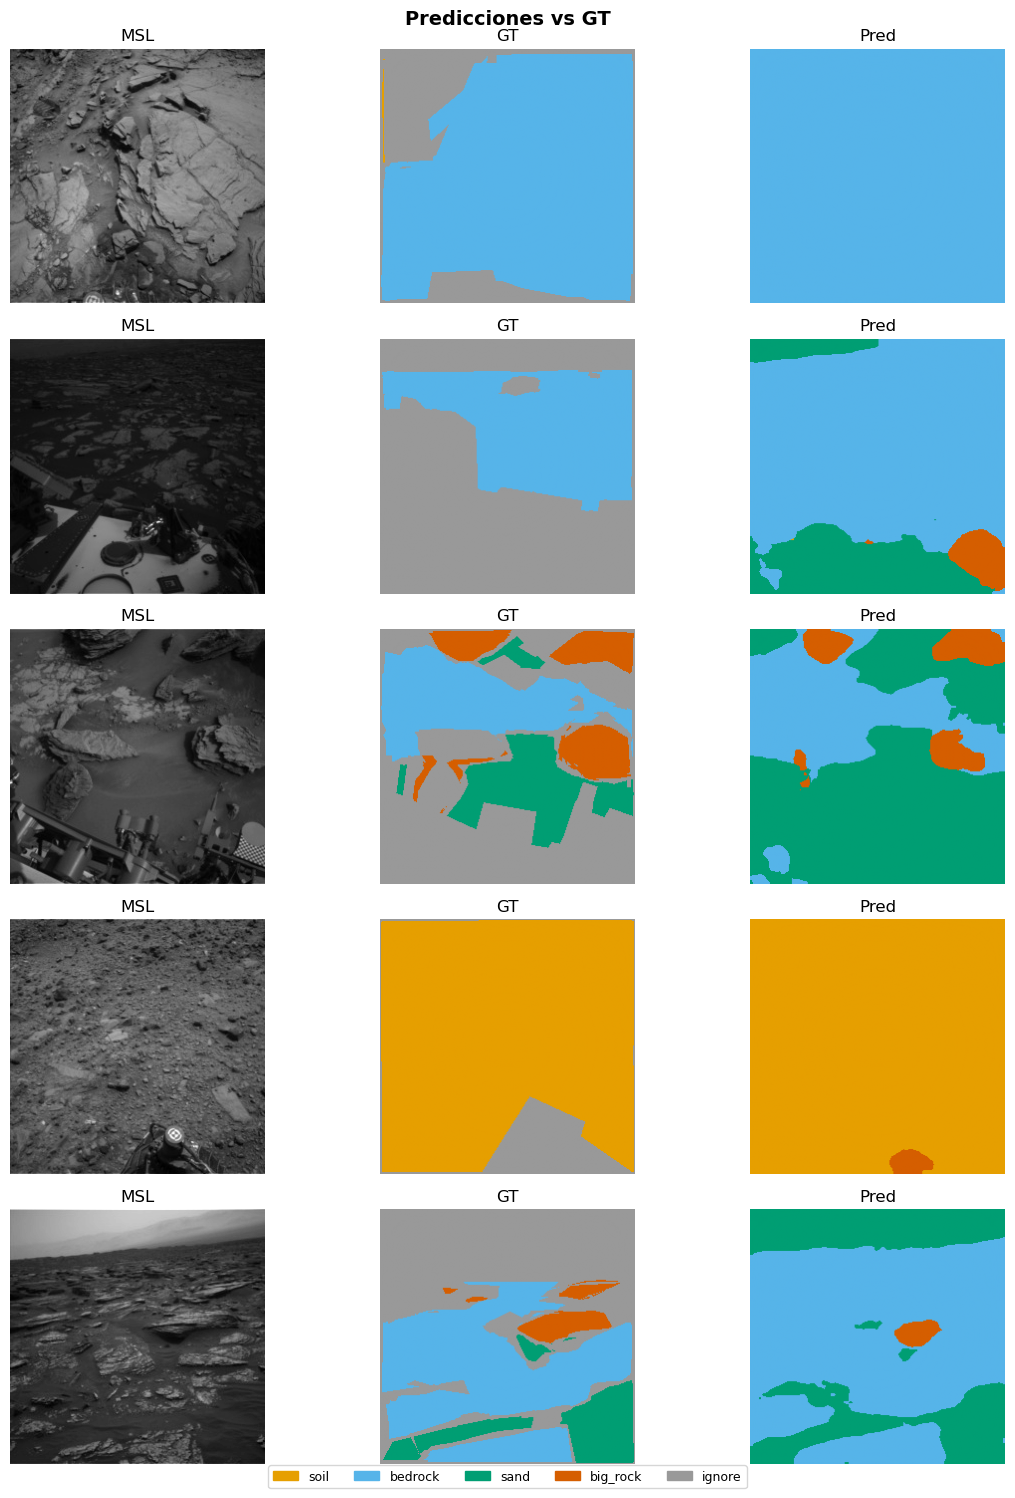

✅ results/terseg_predictions.png
mIoU: 0.7498 ± 0.0089


In [8]:
append_benchmark_results(
    model_name=MODEL_NAME, best_epoch=summary["best_epoch_mean"],
    val_miou=summary["mIoU_mean"], test_miou=summary["mIoU_mean"],
    test_miou_std=summary["mIoU_std"], test_miou_ci95=summary["mIoU_ci95"],
    test_acc=summary["pixel_acc_mean"],
    iou_soil=summary["iou_soil_mean"], iou_bedrock=summary["iou_bedrock_mean"],
    iou_sand=summary["iou_sand_mean"], iou_bigrock=summary["iou_big_rock_mean"],
    params_M=params_M, train_time_s=summary["train_time_mean"],
)
best_model = build_terseg().to(device)
ckpt = torch.load(f"checkpoints/{MODEL_NAME}_seed42_best.pth", map_location=device)
best_model.load_state_dict(ckpt["model_state"])
visualize_predictions(best_model, df_test, device, n=5, save_path=f"results/{MODEL_NAME}_predictions.png")
print(f"mIoU: {summary['mIoU_mean']:.4f} ± {summary['mIoU_std']:.4f}")
